# Artificial Intelligence (DAT6002) Week-6
## Workshop Activity 2: Training and Performance Evaluation of ANN using Validation

### Module Leader: Imtiaz Hussain Khan, PhD 

#### <b style= 'color: blue'> The objective of this activity is to demonstrate how an ANN is trained, how the training can be controlled using validation to minimise over-/underfitting and how its performance is evaluated without using library functions. It also includes training, validation and testing phases. </b>

## Import libraries

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
# Loading the dataset
df = pd.read_csv('diabetes.csv')

In [4]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Spliting dataset into training, validation and testing sets, without using ML libraries

In [5]:
# Training data = 60%, Validation = 20% and Testing = 20%
# Split data frame into 60/40
train_df = df.sample(frac = 0.6)

In [6]:
# Creating dataframe with rest of the 40% values
temp_df = df.drop(train_df.index)

val_df =                                                                     # Complete the missing code

test_df = temp_df.drop(val_df.index)

In [7]:
print(train_df.shape, val_df.shape, test_df.shape)

(461, 9) (154, 9) (153, 9)


# Separating input features from output label

In [8]:
# Extract input features (Pregnancies, Glucose, BMI and Age) and save in the inputs variable
# Separate input features from the class label

feature_cols = ['Pregnancies', 'Glucose', 'BMI', 'Age']

X_train, y_train = train_df[feature_cols], train_df.Outcome

X_val, y_val = val_df[feature_cols], val_df.Outcome

X_test, y_test = test_df[feature_cols], test_df.Outcome

# Normalise the input features

In [9]:
def normalise_data(inputs):
    inputs_min = inputs.min()
    inputs_max = inputs.max()
    inputs = (inputs - inputs_min) / (inputs_max - inputs_min)
    return inputs

In [10]:
X_train_norm = normalise_data(X_train)

In [11]:
X_val_norm =                                                                      # Complete the missing code

In [12]:
X_test_norm =                                                                     # Complete the missing code

# Converting dataset to numpy arrays 

In [13]:
# Training dataset
inputs_array_train = np.array(X_train_norm)
outputs_array_tarin = np.array(y_train)

# Validation dataset
inputs_array_val =                                                            # Complete the missing code
outputs_array_val =                                                           # Complete the missing code

# Testing dataset
inputs_array_test = np.array(X_test_norm)
outputs_array_test = np.array(y_test)

## Converting output vector to matrix

In [14]:
outputs_array_tarin = outputs_array_tarin.reshape(-1, 1)

outputs_array_val =                                                         # Complete the missing code

outputs_array_test =                                                        # Complete the missing code

# Size of hidden and output layer

In [15]:
# Let's use 10 neurons at the hidden layer and 1 neuron at the output layer
hidden_size =                                                              # Complete the missing code

output_size =                                                              # Complete the missing code

# Weights and bias initilisation

In [16]:
weights_0 = np.random.randn(inputs_array_train.shape[1], hidden_size) 

weights_1 = np.random.randn(hidden_size, 1)

In [17]:
b1 = np.zeros((1, hidden_size))

b2 = np.zeros((1, output_size))

## Activation functions and their deratives

In [18]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Feedforward computation function definition

In [19]:
def feedForward(X):
    global weights_0, weights_1, b1, b2
    input_layer = X
    sum_synapse0 = np.dot(input_layer, weights_0) + b1
    hidden_layer = sigmoid(sum_synapse0)
    
    sum_synapse1 = np.dot(hidden_layer, weights_1) + b2
    output_layer = sigmoid(sum_synapse1)
    
    return input_layer, hidden_layer, output_layer

# Backpropagation at output layer function definition

In [20]:
def backPropagation(output_layer):
    global outputs_array_tarin
    error_output_layer = outputs_array_tarin - output_layer
    average_error = np.mean(abs(error_output_layer))
    
    derivative_output = sigmoid_derivative(output_layer)
    delta_output = error_output_layer * derivative_output

    return delta_output, average_error

# Backpropagation at hidden layer function definition

In [21]:
def backPropagationHidden(delta_output, hidden_layer):
    global weights_1
    weights_1T = weights_1.T
    delta_output_weight = delta_output.dot(weights_1T)
    delta_hidden_layer = delta_output_weight * sigmoid_derivative(hidden_layer)
    
    hidden_layerT = hidden_layer.T
    input_x_delta1 = hidden_layerT.dot(delta_output)

    return delta_hidden_layer, input_x_delta1

# Weight and bias update step

In [22]:
def weightBiasUpdate(input_layer, input_x_delta1, delta_hidden_layer, delta_output):
    global weights_0, weights_1, b1, b2, learning_rate
    weights_1 = weights_1 + (input_x_delta1 * learning_rate)
    
    input_layerT = input_layer.T
    input_x_delta0 = input_layerT.dot(delta_hidden_layer)
    weights_0 =                                                                 # Complete the missing code

    b1 +=                                                                       # Complete the missing code
    b2 +=                                                                       # Complete the missing code

# ANN Main Loop

In [23]:
epochs = 10000
learning_rate = 0.01
training_error = []
validation_error = []

best_val_loss = float('inf')
patience = 10                # If validation error doesn't improve in 10 successive epochs, training would stope
counter = 0


for epoch in range(epochs):
    # Training phase
    input_layer, hidden_layer, output_layer = feedForward(X_train_norm)                                    # Calling feedForward method

    delta_output, average_training_error = backPropagation(output_layer)                                   # Calling backPropagation method

    delta_hidden_layer, input_x_delta1 = backPropagationHidden(delta_output, hidden_layer)                # Calling backPropagationHidden method

    weightBiasUpdate(input_layer, input_x_delta1, delta_hidden_layer, delta_output)                       # Calling weightBiasUpdate method

    # Validation phase

    _, _, output_layer_1 = feedForward(X_val_norm)  

    error_output_layer_val = outputs_array_val - output_layer_1
    average_validation_error =                                               # Complete the missing code

    
    if average_validation_error < best_val_loss:
        best_val_loss = average_validation_error
        
        # save model
        best_weights_0 = weights_0.copy()
        best_weights_1 =                                                    # Complete the missing code
        best_b1 =                                                           # Complete the missing code
        best_b2 =                                                           # Complete the missing code
        
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

    # Training and validation error recording
    if epoch % 100 == 0:
        print('Epoch: ' + str(epoch + 1) + ' Training Error: ' + str(average_training_error) + ' Validation Error: ' + str(average_validation_error))
        training_error.append(average_training_error)
        validation_error.append(average_validation_error)

Epoch: 1 Training Error: 0.5465811966531977 Validation Error: 0.44992863436062003
Epoch: 101 Training Error: 0.42402021661400663 Validation Error: 0.41985346374485505
Epoch: 201 Training Error: 0.3789899503384431 Validation Error: 0.3829195926845986
Epoch: 301 Training Error: 0.3474918947018807 Validation Error: 0.3586097604234546
Epoch: 401 Training Error: 0.33124474075115284 Validation Error: 0.3472931427013804
Epoch: 501 Training Error: 0.3228433519221104 Validation Error: 0.34248045111995795
Epoch: 601 Training Error: 0.3181915832474114 Validation Error: 0.34047941793952163
Epoch: 701 Training Error: 0.31543834281678346 Validation Error: 0.33964519616405275
Epoch: 801 Training Error: 0.3137016622540448 Validation Error: 0.33926146100963916
Epoch: 901 Training Error: 0.3125301362892658 Validation Error: 0.33901593608850383
Epoch: 1001 Training Error: 0.3116806326842399 Validation Error: 0.3387757500689841
Epoch: 1101 Training Error: 0.31101850352840454 Validation Error: 0.3384893705

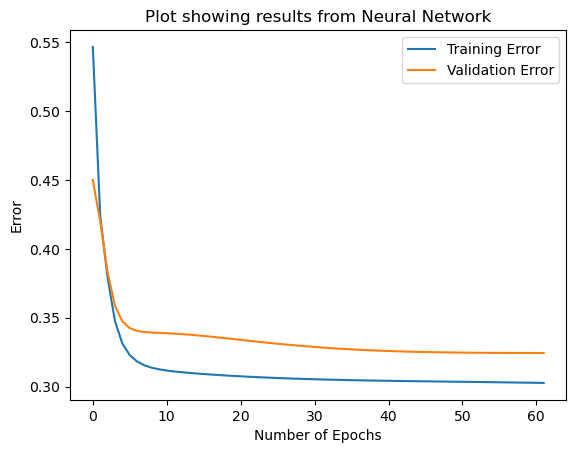

In [24]:
plt.xlabel('Number of Epochs')
plt.ylabel('Error')
plt.title('Plot showing results from Neural Network')

plt.plot(training_error, label='Training Error')
plt.plot(validation_error, label='Validation Error')

plt.legend()   # Show labels
plt.show()

# Testing the ANN on test data

In [25]:
# We'll use only the feedForward pass for testing using the best model parameters

weights_0 =                                          # Complete the missing code
weights_1=                                           # Complete the missing code 
b1 =                                                 # Complete the missing code 
b2 =                                                 # Complete the missing code 

_, _, output_layer = feedForward(X_test_norm) 

# Performance evaluation

In [26]:
# We assume that if ANN's output is greater than 0.5 then prediction is 1 otherwise it is 0

Predicted_Output = (output_layer >= 0.5).astype(int)

### Computing confusion matrix

In [27]:
def confusion_metrics(Y_true, Y_pred):
    TP = np.sum((Y_pred == 1) & (Y_true == 1))
    TN = np.sum((Y_pred == 0) & (Y_true == 0))
    FP = np.sum((Y_pred == 1) & (Y_true == 0))
    FN = np.sum((Y_pred == 0) & (Y_true == 1))
    return TP, TN, FP, FN

In [28]:
TP, TN, FP, FN = confusion_metrics(outputs_array_test, Predicted_Output)

In [29]:
print(f"TP : {TP}, TN : {TN}, FP : {FP}, FN : {FN}")

TP : 24, TN : 87, FP : 14, FN : 28


### Computing performance metrics

In [30]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

In [31]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_score:.4f}")

Accuracy : 0.7255
Precision: 0.6316
Recall   : 0.4615
F1 Score : 0.5333


# Experiment with different learning rates and patience values to see how early stopping is impacted.